In [1]:
import numpy as np
import nibabel as nib
import os
import matplotlib.pyplot as plt
import pandas as pd
from convert_fm import convert_img_ppm_to_Hz_data, convert_ppm_data_to_Hz_data
from demod import demod_pls
from extract_metric import extract_metrics

# <span style="color:orange"> *db0_chi_018 processing* </span> 

In [ ]:
path_to_fms = r"Z:\neuropoly_data\chi_fitting\fm\sim\fms\chi_018_sim_fm_ppm.nii.gz" # Simulation
path_to_dmod_mask = r"Z:\neuropoly_data\chi_fitting\fm\sim\D2_D3_masks\t1w_wholebody_sc_msk.nii.gz" # Simulation
path_to_labeled_cord = r"Z:\neuropoly_data\chi_fitting\fm\sim\D2_D3_masks\t1w_wholebody_sc_msk_labeled.nii.gz" # Simulation
path_to_metrics = r"Z:\neuropoly_data\chi_fitting\fm\sim\D4_metrics"
path_to_dmod_folder = r"Z:\neuropoly_data\chi_fitting\fm\V1_dmod_sim"

## Measured B0 - Inspiration & Expiration

### <span style="color:green"> Expiration </span> 

In [10]:
path_to_exp_meas = r"Z:\neuropoly_data\chi_fitting\fm\C1_meas\exp\fm_tests\mskd_exp_fm\B0.nii"
path_to_exp_dmod_mask = r"Z:\neuropoly_data\chi_fitting\fm\C1_meas\exp\exp_sc_msk.nii.gz"
path_to_exp_metric_mask = r"Z:\neuropoly_data\chi_fitting\fm\C1_meas\exp\vertlevel_registered_to_EXP.nii.gz"

In [11]:
# Load images and get nifti data to manipulate!
exp_B0_meas_img = nib.load(path_to_exp_meas)
exp_B0_meas_data = exp_B0_meas_img.get_fdata()

exp_dmod_mask_img = nib.load(path_to_exp_dmod_mask)
exp_dmod_mask_data = exp_dmod_mask_img.get_fdata()

exp_metric_mask_img = nib.load(path_to_exp_metric_mask)
exp_metric_mask_data = exp_metric_mask_img.get_fdata()


In [12]:
exp_dmod_value = np.mean(exp_B0_meas_data[exp_dmod_mask_data==1])
print("Expiration demod value: ",exp_dmod_value," Hz")

Expiration demod value:  155.18708652025242  Hz


In [13]:
exp_dmod_B0_meas = exp_B0_meas_data - exp_dmod_value
# Create nifti and save
exp_dmod_B0_meas_img = nib.Nifti1Image(exp_dmod_B0_meas, affine = exp_B0_meas_img.affine)
path_to_exp_dmod_fm = r"Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\exp\exp_dmod_B0_meas.nii.gz"
nib.save(exp_dmod_B0_meas_img,path_to_exp_dmod_fm)

In [14]:
# Extract metrics, plot and save value
exp_B0_metrics_path =  r"Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\exp/exp_metrics.csv"
extract_metrics(path_to_exp_dmod_fm, path_to_exp_dmod_mask, path_to_exp_metric_mask, exp_B0_metrics_path, method='wa', vert="3:15")

Metrics extracted successfully: 
--
Spinal Cord Toolbox (git-unknown-?!?)

sct_extract_metric -i Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\exp\exp_dmod_B0_meas.nii.gz -f Z:\neuropoly_data\chi_fitting\fm\C1_meas\exp\exp_sc_msk.nii.gz -method wa -vert 3:15 -vertfile Z:\neuropoly_data\chi_fitting\fm\C1_meas\exp\vertlevel_registered_to_EXP.nii.gz -perlevel 1 -o Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\exp/exp_metrics.csv
--


Load metric image...
Creating temporary folder (C:\Users\Admin\AppData\Local\Temp\sct_2026-07-13_16-03-01_optic-detect-centerline_k7_0ha44)
Image header specifies datatype 'uint8', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.

Done! To view results, type:
itk-snap -g C:\Users\Admin\AppData\Local\Temp\sct_2026-07-13_16-03-01_optic-detect-centerline_k7_0ha44\vertlevel_registered_to_EXP_ctl_levels.nii.gz

Estimation for label: exp_sc_msk

Remove temporary files...
rm -rf C:\Users\Admin\AppData\Local\Temp\sct_2026-07-13_16-0

In [16]:
exp_B0_metrics_path =  r"Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\exp/exp_metrics.csv"
exp_metrics_df = pd.read_csv(exp_B0_metrics_path)
exp_metrics_data = exp_metrics_df['WA()']
exp_metrics_data = exp_metrics_data[::-1]
exp_metrics_data

12   -111.419840
11   -128.330109
10   -105.593198
9     -59.521238
8       8.472542
7      75.742244
6      74.123506
5      30.759698
4      37.885735
3      51.756722
2      55.848140
1      35.949094
0       3.022444
Name: WA(), dtype: float64

### <span style="color:red"> Inspiration </span> 

In [17]:
path_to_insp_meas = r"Z:\neuropoly_data\chi_fitting\fm\C1_meas\insp\mskd_insp_fm\B0.nii"
path_to_insp_dmod_mask = r"Z:\neuropoly_data\chi_fitting\fm\C1_meas\insp\insp_sc_msk.nii.gz"
path_to_insp_metric_mask = r"Z:\neuropoly_data\chi_fitting\fm\C1_meas\insp\vertlevel_registered_to_INSP.nii.gz"

In [18]:
# Load images and get nifti data to manipulate!
insp_B0_meas_img = nib.load(path_to_insp_meas)
insp_B0_meas_data = insp_B0_meas_img.get_fdata()

insp_dmod_mask_img = nib.load(path_to_insp_dmod_mask)
insp_dmod_mask_data = insp_dmod_mask_img.get_fdata()

insp_metric_mask_img = nib.load(path_to_insp_metric_mask)
insp_metric_mask_data = insp_metric_mask_img.get_fdata()

In [19]:
insp_dmod_value = np.mean(insp_B0_meas_data[insp_dmod_mask_data==1])
print("Inspiration demod value: ",insp_dmod_value," Hz")

Inspiration demod value:  60.47379237131837  Hz


In [20]:
insp_dmod_B0_meas = insp_B0_meas_data - insp_dmod_value
# Create nifti and save
insp_dmod_B0_meas_img = nib.Nifti1Image(insp_dmod_B0_meas, affine = insp_B0_meas_img.affine)
path_to_insp_dmod_fm = r"Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\insp\insp_dmod_B0_meas.nii.gz"
nib.save(insp_dmod_B0_meas_img, path_to_insp_dmod_fm)

In [21]:
insp_B0_metrics_path = r"Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\insp/insp_metrics.csv"
extract_metrics(path_to_insp_dmod_fm, path_to_insp_dmod_mask, path_to_insp_metric_mask, insp_B0_metrics_path, method='wa', vert="3:15")

Metrics extracted successfully: 
--
Spinal Cord Toolbox (git-unknown-?!?)

sct_extract_metric -i Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\insp\insp_dmod_B0_meas.nii.gz -f Z:\neuropoly_data\chi_fitting\fm\C1_meas\insp\insp_sc_msk.nii.gz -method wa -vert 3:15 -vertfile Z:\neuropoly_data\chi_fitting\fm\C1_meas\insp\vertlevel_registered_to_INSP.nii.gz -perlevel 1 -o Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\insp/insp_metrics.csv
--


Load metric image...
Creating temporary folder (C:\Users\Admin\AppData\Local\Temp\sct_2026-07-13_16-07-42_optic-detect-centerline_ruk5b3fy)
Image header specifies datatype 'uint8', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.

Done! To view results, type:
itk-snap -g C:\Users\Admin\AppData\Local\Temp\sct_2026-07-13_16-07-42_optic-detect-centerline_ruk5b3fy\vertlevel_registered_to_INSP_ctl_levels.nii.gz

Estimation for label: insp_sc_msk

Remove temporary files...
rm -rf C:\Users\Admin\AppData\Local\Temp\sct_2026-

In [22]:
insp_B0_metrics_path = r"Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\insp/insp_metrics.csv"
insp_metrics_df = pd.read_csv(insp_B0_metrics_path)
insp_metrics_data = insp_metrics_df['WA()']
insp_metrics_data = insp_metrics_data[::-1]
insp_metrics_data

12   -107.491375
11   -113.442044
10    -74.983684
9      -6.387111
8      79.603938
7     145.858606
6     119.543914
5      32.348946
4      16.118313
3      27.266380
2      16.717258
1      -8.525887
0     -31.233687
Name: WA(), dtype: float64

### <span style="color:#C28AD1"> Average Insp and Exp </span> 

In [23]:
avg_respiration = (exp_metrics_data+ insp_metrics_data )/2
avg_respiration

12   -109.455607
11   -120.886076
10    -90.288441
9     -32.954174
8      44.038240
7     110.800425
6      96.833710
5      31.554322
4      27.002024
3      39.511551
2      36.282699
1      13.711603
0     -14.105621
Name: WA(), dtype: float64

In [24]:
# Export average!
avg_respiration.to_csv(r"Z:\neuropoly_data\chi_fitting\fm\C_dmod_meas\simple_avg_respiration.csv" , index = False, header = True)

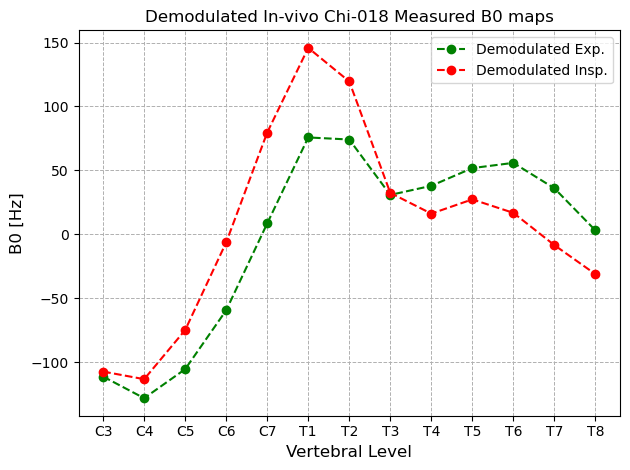

In [27]:
# Correct for phase wraps the Expiration:
#exp_corrected_metrics = raw_exp_metrics - np.abs(freq_offset_npi)
vertebrae_levelsC3_T8 = ['C3','C4', 'C5', 'C6', 'C7', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8'] # From 4 to 14
plt.plot(vertebrae_levelsC3_T8, exp_metrics_data, marker = 'o', linestyle = '--', label = "Demodulated Exp.", color = "green")
plt.plot(vertebrae_levelsC3_T8, insp_metrics_data, marker = 'o', linestyle = '--', label = "Demodulated Insp.", color = "red")

plt.title("Demodulated In-vivo Chi-018 Measured B0 maps")
plt.xlabel('Vertebral Level', fontsize=12)
plt.ylabel('B0 [Hz]', fontsize=12)
plt.legend()
# Customize grid and display
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.tight_layout()

# Show the plot
plt.show()

### Simualted FM loading, demod, extract metric and plot!
The path_to_fm variable will contain 1 to n number of fms that we want to extract, demodulated and extract metrics

In [25]:
from convert_fm import convert_ppm_data_to_Hz_data
from extract_metric import extract_metrics
import re

dmod_mask_img = nib.load(path_to_dmod_mask)
dmod_mask_data = dmod_mask_img.get_fdata()

metric_mask_img = nib.load(path_to_labeled_cord)
metric_mask_data = metric_mask_img.get_fdata()

In [28]:
path_to_curr_fm = path_to_fms
current_fm_img = nib.load(path_to_curr_fm)
current_fm_data = current_fm_img.get_fdata()
    
 # Now, demodulationg by the average over the mask -> demod mask
demod_value = np.mean(current_fm_data[dmod_mask_data==1])
print(f"Demod value for sim_chi_018:",demod_value)

curr_dmod_fm_ppm = current_fm_data - demod_value
dmod_fm_Hz = convert_ppm_data_to_Hz_data(curr_dmod_fm_ppm,3)
dmod_fm_Hz_name = "sim_chi_018_dmod_B0_Hz.nii.gz"
dmod_save_path = os.path.join(path_to_dmod_folder, dmod_fm_Hz_name)
dmod_fm_img = nib.Nifti1Image(dmod_fm_Hz, affine = current_fm_img.affine)
nib.save(dmod_fm_img,dmod_save_path)

# Now metric extraction + saving and plotting :)

Demod value for sim_chi_018: -2.7906583812252053


In [ ]:
path_to_metrics
dmod_fm_Hz_name = "sim_chi_018_dmod_B0_Hz.nii.gz"

'Z:\\neuropoly_data\\chi_fitting\\fm\\sim\\D4_metrics'

In [30]:
path_to_dmod_fm = os.path.join(path_to_dmod_folder, dmod_fm_Hz_name)

sim_metrics_outfn = os.path.join(path_to_metrics, "sim_chi_018_dmod_metrics.csv")
extract_metrics(path_to_dmod_fm, path_to_dmod_mask, path_to_labeled_cord, sim_metrics_outfn, method='wa', vert="3:15")


Metrics extracted successfully: 
--
Spinal Cord Toolbox (git-unknown-?!?)

sct_extract_metric -i Z:\neuropoly_data\chi_fitting\fm\V1_dmod_sim\sim_chi_018_dmod_B0_Hz.nii.gz -f Z:\neuropoly_data\chi_fitting\fm\sim\D2_D3_masks\t1w_wholebody_sc_msk.nii.gz -method wa -vert 3:15 -vertfile Z:\neuropoly_data\chi_fitting\fm\sim\D2_D3_masks\t1w_wholebody_sc_msk_labeled.nii.gz -perlevel 1 -o Z:\neuropoly_data\chi_fitting\fm\sim\D4_metrics\sim_chi_018_dmod_metrics.csv
--


Load metric image...
Creating temporary folder (C:\Users\Admin\AppData\Local\Temp\sct_2026-07-13_16-25-48_optic-detect-centerline_aiasjoov)
Image header specifies datatype 'uint8', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.

Done! To view results, type:
itk-snap -g C:\Users\Admin\AppData\Local\Temp\sct_2026-07-13_16-25-48_optic-detect-centerline_aiasjoov\t1w_wholebody_sc_msk_labeled_ctl_levels.nii.gz

Estimation for label: t1w_wholebody_sc_msk

Remove temporary files...
rm -rf C:\Users\

In [31]:
# Load simulated metrics
dmod_sim_metrics = r"Z:\neuropoly_data\chi_fitting\fm\sim\D4_metrics\sim_chi_018_dmod_metrics.csv"
dmod_sim_metrics_df = pd.read_csv(dmod_sim_metrics)
dmod_sim_metrics_data = dmod_sim_metrics_df['WA()']
dmod_sim_metrics_data = dmod_sim_metrics_data[::-1]
dmod_sim_metrics_data

12   -238.405764
11   -245.014331
10   -219.123618
9    -164.284904
8     -88.767895
7      -7.646667
6      27.355915
5      10.032776
4      18.447416
3      52.394965
2      85.859697
1     100.788893
0     103.044130
Name: WA(), dtype: float64

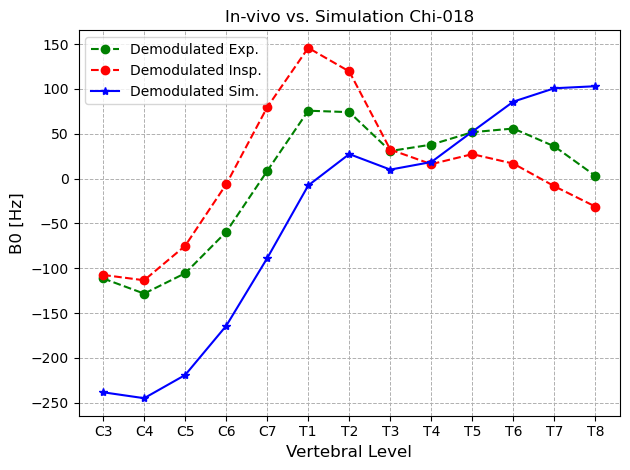

In [32]:
# Correct for phase wraps the Expiration:
#exp_corrected_metrics = raw_exp_metrics - np.abs(freq_offset_npi)
vertebrae_levelsC3_T8 = ['C3','C4', 'C5', 'C6', 'C7', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8'] # From 4 to 14
plt.plot(vertebrae_levelsC3_T8, exp_metrics_data, marker = 'o', linestyle = '--', label = "Demodulated Exp.", color = "green")
plt.plot(vertebrae_levelsC3_T8, insp_metrics_data, marker = 'o', linestyle = '--', label = "Demodulated Insp.", color = "red")
plt.plot(vertebrae_levelsC3_T8, dmod_sim_metrics_data, marker = '*', linestyle = '-', label = "Demodulated Sim.", color = "blue")
plt.title("In-vivo vs. Simulation Chi-018")
plt.xlabel('Vertebral Level', fontsize=12)
plt.ylabel('B0 [Hz]', fontsize=12)
plt.legend()
# Customize grid and display
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.tight_layout()

# Show the plot
plt.show()
